Setting Model with Modifications 

import 

In [1]:
import os
os.chdir(r"C:/Users/priya/UVA-iGEM-2025-Model-/ECMpy")
print(os.getcwd())
import cobra 
from cobra.io import save_json_model, write_sbml_model
from cobra import Model, Reaction, Metabolite
import pandas as pd
import sys
sys.path.append(r'./code/')
from cobrapy_ec_model_function import *
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import cobra.test
from cobra.flux_analysis import production_envelope

C:\Users\priya\UVA-iGEM-2025-Model-\ECMpy


In [2]:
#input files
model_ori_file=r'C:\Users\priya\UVA-iGEM-2025-Model-\ECMpy\iML1515.xml'
gpr_modify_file='./data/model change file/iML1515-modify_gpr.csv'
reaction_direction_change_file='./data/model change file/iML1515_direction_change-58.csv'
reaction_ec_adj_file='./data/model change file/reaction_ec_adj.csv'

model = cobra.io.read_sbml_model(model_ori_file)

#output files
model_xml_file="./model/iML1515_new.xml"
model_json_file="./model/iML1515_new.json"

In [3]:
gpr_modify_df = pd.read_csv(gpr_modify_file,index_col='id')

change_rxn_gpr_list = list(gpr_modify_df.index[0:14])
print(len(change_rxn_gpr_list))

for r in model.reactions:
    if r.id in change_rxn_gpr_list:
        r.gene_reaction_rule = gpr_modify_df.loc[r.id]['Modified genes ']
        print(r,r.gene_reaction_rule)

14
FMNRx2: fmn_c + h_c + nadph_c --> fmnh2_c + nadp_c b0937 or b3844 or b2764
ARGabcpp: arg__L_p + atp_c + h2o_c --> adp_c + arg__L_c + h_c + pi_c ( b2310 and b2308 and b2306 and b2307 ) or ( b0862 and b0860 and b0864 and b0861 ) or ( b0862 and b0864 and b0863 and b0861 )
ECAP1pp: 2.0 unagamuf_p --> eca2und_p + h_p + udcpdp_p b3785 and b3793 and b3792
ECAP2pp: eca2und_p + unagamuf_p --> eca3und_p + h_p + udcpdp_p b3785 and b3793 and b3792
3NTD4pp: 3cmp_p + h2o_p --> cytd_p + pi_p b0383 or b4213 or b2744
GLUDy: glu__L_c + h2o_c + nadp_c <=> akg_c + h_c + nadph_c + nh4_c b1761
ECAP3pp: eca3und_p + unagamuf_p --> eca4und_p + h_p + udcpdp_p b3785 and b3793 and b3792
FADRx2: fad_c + h_c + nadph_c --> fadh2_c + nadp_c b2764
BWCOGDS1: bwco_c + gtp_c + h_c --> bwco1gdp_c + ppi_c b3857
BWCOGDS2: bwco1gdp_c + gtp_c + h_c --> bwcogdp_c + ppi_c b3857
MOGDS: gtp_c + h_c + moco_c --> mocogdp_c + ppi_c b3857
THZPSN3: atp_c + dhgly_c + dxyl5p_c + h_c + iscssh_c + nadph_c --> 4mpetz_c + amp_c + co2_c +

In [4]:
change_direction_df = pd.read_csv(reaction_direction_change_file,index_col='id')

for r in model.reactions:
    for i in change_direction_df.index:
        if r.id==i:
            if change_direction_df.loc[i]['after']=='forward':
                r.bounds=(0,1000)
            if change_direction_df.loc[i]['after']=='backward':
                r.bounds=(-1000,0)

In [5]:
model.reactions.get_by_id('SHK3Dr').bounds = (0,1000)
model.reactions.get_by_id('SHK3Dr').id = 'SHK3Dr'
model.reactions.get_by_id('SHK3Dr').gene_reaction_rule = 'b3281'

reaction = Reaction('SHK3Dr_reverse')
model.add_reaction(reaction)
reaction.build_reaction_from_string('3dhsk_c + h_c + nadph_c <-- nadp_c + skm_c')
model.reactions.get_by_id('SHK3Dr_reverse').gene_reaction_rule = 'b1692'

In [6]:
reaction_ec_adj_df = pd.read_csv(reaction_ec_adj_file,index_col='reaction')
for r in model.reactions:
    if r.id in reaction_ec_adj_df.index:
        r.annotation["ec-code"] = reaction_ec_adj_df.loc[r.id,'ec']
        print(r.id,r.annotation["ec-code"])

MDH3 1.1.5.4
MDH2 1.1.5.4


Gapfilling Reactions 

In [7]:
scys__L_c = Metabolite("scys__L_c", name="S-sulfocysteine", compartment="c")
model.add_metabolites([scys__L_c])

# Reaction 1: SLCYSS
slcyss = Reaction("SLCYSS")
slcyss.name = "O-acetyl-L-serine sulfhydrylase"
slcyss.lower_bound = 0 
slcyss.upper_bound = 1000

acser_c = model.metabolites.get_by_id("acser_c")
tsul_c = model.metabolites.get_by_id("tsul_c")
ac_c = model.metabolites.get_by_id("ac_c")

slcyss.add_metabolites({
    acser_c: -1,
    tsul_c: -1,
    ac_c: 1,
    scys__L_c: 1
})
slcyss.gene_reaction_rule = "b2421"  # CysM
model.add_reactions([slcyss])

# Reaction 2: SCYSSL
scyssl = Reaction("SCYSSL")
scyssl.name = "S-sulfo-L-cysteine sulfite lyase"
scyssl.lower_bound = 0
scyssl.upper_bound = 1000

gthrd_c = model.metabolites.get_by_id("gthrd_c")
gthox_c = model.metabolites.get_by_id("gthox_c")
cys__L_c = model.metabolites.get_by_id("cys__L_c")
h_c = model.metabolites.get_by_id("h_c")
so3_c = model.metabolites.get_by_id("so3_c")

scyssl.add_metabolites({
    gthrd_c: -2,
    scys__L_c: -1,
    cys__L_c: 1,
    gthox_c: 1,
    h_c: 1,
    so3_c: 1
})

# Add to model
model.add_reactions([scyssl])


In [8]:
cobra.io.write_sbml_model(model, model_xml_file)

In [9]:
cobra.io.save_json_model(model, model_json_file)

Model without calibration 

In [10]:
# The genome-scale metabolic model for constructing the enzyme-constrained model
model_name = './model/iML1515_new.xml' 

# Reaction-kcat file.
# eg. AADDGT,64.41327046 #s-1
reaction_kcat_file = './data/nc_machine_learning_kapp.json'
select_key = 'kappmax_ensemble_model_s-1'

# Gene-abundance file organized from PAXdb
# eg. b0789,1.1
gene_abundance_file = "./data/parsed_gene_abundance_from_paxdb.csv"

# Gene-molecular_weight file organized from EcoCyc
# eg. b3500,48.77251
gene_molecular_weight_file = "./data/gene_molecular_weight.csv"

reaction_gene_subunit_file = "./data/reaction_gene_subunit.csv"
c13reaction_file = './data/C13reaction.csv' 
media_file = './data/final_media(final_media).csv'


#output files
gene_outfile = "./analysis/genes.csv"
gpr_outfile = "./analysis/all_reaction_GPR.csv"
reaction_gene_subunit_MW_file = "./analysis/reaction_gene_subunit_MW.csv"
reaction_MW_file = "./analysis/reaction_MW.csv"
reaction_kcat_MW_file = "./analysis/reaction_kcat_MW.csv"
json_output_file="./model/iML1515_irr_enz_constraint.json"
ECMpy_fluxes_outfile = './analysis/ECMpy_ori_solution_df_pfba.csv'
GEM_fluxes_outfile = './analysis/Orimodel_solution_df_pfba.csv'

In [12]:
model = cobra.io.read_sbml_model(model_name)
#modifying bounds to account for reversible reactions for media conditions 
df = pd.read_csv(media_file)
df.columns = df.columns.str.strip()
for _, row in df.iterrows():
    rxn_id = row['Original Reaction']

    # Only proceed if the reaction ID is present and non-null
    if pd.notna(rxn_id):
        try:
            rxn = model.reactions.get_by_id(rxn_id)
            rxn.lower_bound = -1000.0  # allow uptake
            # Optionally: cap export if you want to avoid unintended fluxes
            # rxn.upper_bound = 1000.0  
        except KeyError:
            print(f"⚠️ Reaction {rxn_id} not found in model, skipping.")

print(model.reactions.get_by_id('EX_xyl__D_e').bounds)
convert_to_irreversible(model)
#split isoenzyme
model = isoenzyme_split(model)
model
modified_model = cobra.io.write_sbml_model(model, 'modified_model.xml')

(-1000.0, 1000.0)


In [13]:
[genes,gpr_relationship] = get_genes_and_gpr(model,gene_outfile,gpr_outfile)

In [14]:
reaction_gene_subunit_MW = get_reaction_gene_subunit_MW(reaction_gene_subunit_file,gene_molecular_weight_file,reaction_gene_subunit_MW_file)
reaction_gene_subunit_MW.head(5)

,name,gene_reaction_rule,subunit_num,subunit_mw
ALATA_D2_num1,D-alanine transaminase,b2551,2,45.31659
ALATA_D2_num2,D-alanine transaminase,b0870,4,36.49471
SHCHD2,Sirohydrochlorin dehydrogenase (NAD),b3368,2,49.9514
CPPPGO,Coproporphyrinogen oxidase (O2 required),b2436,2,34.32263
GTHOr,Glutathione oxidoreductase,b3500,2,48.77251


In [15]:
# reaction-gene-subunit-MW file. 
# eg. ALATA_D2,D-alanine transaminase,b2551 or b0870,45.31659 or 36.49471 ,2 or 4 
reaction_MW = calculate_reaction_mw(reaction_gene_subunit_MW_file,reaction_MW_file)
reaction_MW.head(5)

,MW
ALATA_D2_num1,90.6332
ALATA_D2_num2,145.9788
SHCHD2,99.9028
CPPPGO,68.6453
GTHOr,97.545


In [16]:
reaction_kcat_mw = calculate_reaction_kcat_mw(reaction_kcat_file, reaction_MW_file, reaction_kcat_MW_file,select_key)
reaction_kcat_mw.head(5)

,MW,kcat,kcat_MW
ALATA_D2_num1,90.6332,9300.506998,102.616999
ALATA_D2_num2,145.9788,9300.506998,63.711354
SHCHD2,99.9028,1224.000000,12.251909
CPPPGO,68.6453,900.000000,13.110876
GTHOr,97.5450,25901.616143,265.535047


In [17]:
f = calculate_f(genes, gene_abundance_file, gene_molecular_weight_file)
f

0.9521446776017833

In [18]:
#The enzyme mass fraction 
f = f
print(f)
# The total protein fraction in cell.
ptot = 0.56 
# The approximated average saturation of enzyme.
sigma = 1 #kapp data sigma is 1
# Lowerbound  of enzyme concentration constraint. 
lowerbound = 0   
upperbound = round(ptot * f * sigma, 3)

0.9521446776017833


In [19]:
#create enzyme concentration constraint model
#trans_model2enz_json_model_split_isoenzyme(model_name, reaction_kcat_MW_file, f, ptot, sigma, lowerbound, upperbound, json_output_file)
trans_model2enz_json_model_split_isoenzyme('modified_model.xml', reaction_kcat_MW_file, f, ptot, sigma, lowerbound, upperbound, json_output_file)

enz_model=get_enzyme_constraint_model(json_output_file)
#enz_model.objective = 'EX_cys__L_e'
#print(enz_model.objective.expression)
#enz_model_pfba_solution = get_fluxes_detail_in_model(enz_model,ECMpy_fluxes_outfile,reaction_kcat_MW_file)
#print("ecLCYS:", enz_model_pfba_solution.fluxes['EX_cys__L_e'])
#print("ecBIOMASS:", enz_model_pfba_solution.fluxes['BIOMASS_Ec_iML1515_core_75p37M'])

#enz_model.objective = 'BIOMASS_Ec_iML1515_core_75p37M'
#print(enz_model.objective.expression)
#enz_model_pfba_solution = get_fluxes_detail_in_model(enz_model,ECMpy_fluxes_outfile,reaction_kcat_MW_file)
#print("ecLCYS2:", enz_model_pfba_solution.fluxes['EX_cys__L_e'])
#print("ecBIOMASS2:", enz_model_pfba_solution.fluxes['BIOMASS_Ec_iML1515_core_75p37M'])

#norm_model = cobra.io.json.load_json_model(json_output_file)
#norm_model.objective = 'EX_cys__L_e'
#norm_model_pfba_solution = cobra.flux_analysis.pfba(norm_model)
#norm_model_pfba_solution_df = norm_model_pfba_solution.to_frame()
#norm_model_pfba_solution_df.to_csv(GEM_fluxes_outfile)
#print("LCYS:", norm_model_pfba_solution_df.fluxes['EX_cys__L_e'])
#print("BIOMASS:", norm_model_pfba_solution.fluxes['BIOMASS_Ec_iML1515_core_75p37M'])

#norm_model.objective = 'BIOMASS_Ec_iML1515_core_75p37M'
#norm_model_pfba_solution = cobra.flux_analysis.pfba(norm_model)
#norm_model_pfba_solution_df = norm_model_pfba_solution.to_frame()
#norm_model_pfba_solution_df.to_csv(GEM_fluxes_outfile)
#print("LCYS:", norm_model_pfba_solution_df.fluxes['EX_cys__L_e'])
#print("BIOMASS:", norm_model_pfba_solution.fluxes['BIOMASS_Ec_iML1515_core_75p37M'])

#Compare with C13 data
#c13reaction_2_enz_model_diff = get_diff_reaction_use_c13(c13reaction_file,enz_model_pfba_solution)
#print (c13reaction_2_enz_model_diff)

Model with enzyme usage calibration 

In [20]:
#enyme model needed data
#The enzyme mass fraction 
f = f
# The total protein fraction in cell.
ptot = 0.56 
# The approximated average saturation of enzyme.
sigma = 1 #kapp data sigma is 1
# Lowerbound  of enzyme concentration constraint. 
lowerbound = 0   
upperbound = round(ptot * f * sigma, 3)

new_model_name = './modified_model.xml' 
c13reaction_file = './data/C13reaction.csv' 

#max kcat for EC number selected from BRENDA and SABIO-RK database(use autoPACMEN)
kcat_database_combined_file= './data/Brenda_sabio_combined_select.json'

reaction_kcat_MW_file = './analysis/reaction_kcat_MW.csv'
fluxes_infile_ori = './analysis/ECMpy_ori_solution_df_pfba.csv'
json_model_path = './model/iML1515_irr_enz_constraint.json'

enz_ratio=0.01
reaction_enz_usage_file = './analysis/ECMpy_adj_round1_reaction_enz_usage_df.csv'
reaction_kcat_MW_round1_outfile = './analysis/reaction_change_by_enzuse.csv'
json_round1_output_file = './model/iML1515_irr_enz_constraint_adj_round1.json'
round1_fluxes_outfile = './analysis/ECMpy_adj_round1_solution_df_pfba.csv'
c13_percentage=0.1
#json_round2_output_file= './model/iML1515_irr_enz_constraint_adj_round2.json'
#reaction_kcat_MW_round2_outfile = './analysis/reaction_change_by_c13.csv'
#round2_fluxes_outfile = './analysis/ECMpy_adj_round2_solution_df_pfba.csv'

ECMpy_solution_df_pfba_file='./analysis/ECMpy_solution_df_pfba.csv'

In [21]:

enz_model=get_enz_model_use_enz_usage_by_eckcat(enz_ratio,json_model_path,fluxes_infile_ori, reaction_kcat_MW_file,\
                                      reaction_enz_usage_file,kcat_database_combined_file, new_model_name
                                                
                                                , \
                                      f, ptot, sigma, lowerbound, upperbound, json_round1_output_file, \
                                      reaction_kcat_MW_round1_outfile)
enz_model_pfba_solution = get_fluxes_detail_in_model(enz_model,round1_fluxes_outfile,reaction_kcat_MW_round1_outfile)

c13reaction_2_enz_model_diff = get_diff_reaction_use_c13(c13reaction_file,enz_model_pfba_solution)
print (c13reaction_2_enz_model_diff)

need changing reaction: 
['GLCDpp_num2', 'RBFSa', 'ACCOAC', 'ATPS4rpp_num2', 'GLNS', 'CYTBO3_4pp', 'GTPCI', 'MCOATA']
changed reaction: 
['RBFSa', 'ACCOAC', 'GLNS', 'GTPCI', 'MCOATA']
['PSERT', 'ICL', 'PGI', 'PPC', 'FBA', 'SUCDi', 'PYK', 'ACONTb', 'CS', 'PFK', 'AKGDH', 'PGCD', 'PDH', 'PSP_L', 'TPI', 'ACKr_reverse', 'PTAr', 'GHMT2r', 'MDH', 'MALS', 'ICDHyr', 'ACONTa', 'SUCOAS_reverse']


removing calibration for update kcat values

In [22]:
orig_df = pd.read_csv(reaction_kcat_MW_file, header=None)
calib_df = pd.read_csv(reaction_kcat_MW_round1_outfile, header=None)

# Define reactions to protect
protected_rxns = ['PGCD','SERAT','SERAT_reverse']

# Overwrite calibrated kcat with original for protected reactions
for rxn in protected_rxns:
    orig_kcat = orig_df.loc[orig_df[0] == rxn, 2].values
    if len(orig_kcat) > 0:
        calib_df.loc[calib_df[0] == rxn, 2] = orig_kcat[0]

# Save corrected file
calib_df.to_csv(reaction_kcat_MW_round1_outfile, index=False)

In [23]:
#run enzyme constraint metabolic model
enz_model=get_enzyme_constraint_model(json_round1_output_file)
#enz_model.objective = 'EX_cys__L_e'
#pfba_solution = cobra.flux_analysis.pfba(enz_model)
#pfba_solution_df = pfba_solution.to_frame()
#pfba_solution_df.to_csv(ECMpy_solution_df_pfba_file)
#print("ecLCYS:", pfba_solution_df.fluxes['EX_cys__L_e'])
#print("ecBIOMASS:", pfba_solution_df.fluxes['BIOMASS_Ec_iML1515_core_75p37M'])

#enz_model.objective = 'BIOMASS_Ec_iML1515_core_75p37M'
#pfba_solution = cobra.flux_analysis.pfba(enz_model)
#pfba_solution_df = pfba_solution.to_frame()
#pfba_solution_df.to_csv(ECMpy_solution_df_pfba_file)
#print("ecBIOMASS:", pfba_solution_df.fluxes['BIOMASS_Ec_iML1515_core_75p37M'])
#print("ecLCYS:", pfba_solution_df.fluxes['EX_cys__L_e'])

Altering media conditions 

In [32]:
for rxn in enz_model.reactions:
    if rxn.id.endswith('_reverse') and rxn.id.startswith('EX_'):
        rxn.upper_bound = 0.0  # Block uptake

df = pd.read_csv(media_file)
df.columns = df.columns.str.strip()

# Apply bounds to model reactions
for _, row in df.iterrows():
    rxn_id = row['Reverse Reaction']
    uptake_rate = row['sucrose']
    
    # Skip if any value is missing or not a number
    if pd.isna(rxn_id) or pd.isna(uptake_rate):
        continue

    try:
        rxn = enz_model.reactions.get_by_id(rxn_id)
        rxn.upper_bound = float(uptake_rate)  # Positive uptake convention for _reverse
    except KeyError:
        print(f"Reaction {rxn_id} not found in model, skipping.")

print(enz_model.reactions.get_by_id('EX_xyl__D_e_reverse').bounds)
        
#enz_model.reactions.get_by_id('EX_tsul_e_reverse').lower_bound = 10
enz_model.reactions.get_by_id('EX_cys__L_e_reverse').upper_bound = 0
enz_model.reactions.get_by_id('EX_ser__L_e_reverse').upper_bound = 0
enz_model.reactions.get_by_id('EX_thr__L_e_reverse').upper_bound = 10
#enz_model.reactions.get_by_id("EX_so4_e_reverse").upper_bound = 10
enz_model.medium

(0.0, 0.0)


{'EX_pi_e_reverse': 100.0,
 'EX_met__L_e_reverse': 22.53032929,
 'EX_ile__L_e_reverse': 45.06065858,
 'EX_fe3_e_reverse': 100.0,
 'EX_leu__L_e_reverse': 64.12478336,
 'EX_pro__L_e_reverse': 24.26343154,
 'EX_mn2_e_reverse': 100.0,
 'EX_ala__L_e_reverse': 11.89168034,
 'EX_arg__L_e_reverse': 76.26,
 'EX_asp__L_e_reverse': 213.1715771,
 'EX_tyr__L_e_reverse': 20.79722704,
 'EX_glu__L_e_reverse': 46.79376083,
 'EX_btn_e_reverse': 100.0,
 'EX_fe2_e_reverse': 100.0,
 'EX_val__L_e_reverse': 69.32409012,
 'EX_gly_e_reverse': 1.733102253,
 'EX_lys__L_e_reverse': 46.79376083,
 'EX_thm_e_reverse': 100.0,
 'EX_trp__L_e_reverse': 6.932409012,
 'EX_sucr_e_reverse': 100.0,
 'EX_zn2_e_reverse': 100.0,
 'EX_mg2_e_reverse': 100.0,
 'EX_cbl1_e_reverse': 100.0,
 'EX_nac_e_reverse': 100.0,
 'EX_ca2_e_reverse': 100.0,
 'EX_ni2_e_reverse': 100.0,
 'EX_cu2_e_reverse': 100.0,
 'EX_sel_e_reverse': 100.0,
 'EX_cobalt2_e_reverse': 100.0,
 'EX_cit_e_reverse': 100.0,
 'EX_mobd_e_reverse': 100.0,
 'EX_so4_e_reverse

lexicographic optimization

In [33]:
epsilon = 0.9 
enz_model.objective = 'BIOMASS_Ec_iML1515_core_75p37M'
sol1 = enz_model.optimize()
print(sol1) 
z1_opt = sol1.objective_value
print('Biomass:',z1_opt)
lb = z1_opt * (1 - epsilon)  # For maximization case
enz_model.reactions.BIOMASS_Ec_iML1515_core_75p37M.lower_bound = lb
enz_model.objective = 'EX_cys__L_e'

pfba_solution = cobra.flux_analysis.pfba(enz_model)
pfba_solution_df = pfba_solution.to_frame()
pfba_solution_df.to_csv(ECMpy_solution_df_pfba_file)
print("PGCD:", pfba_solution_df.fluxes['PGCD'])
print("SERAT:", pfba_solution_df.fluxes['SERAT'])
print("tsul:", pfba_solution_df.fluxes['EX_tsul_e_reverse'], pfba_solution_df.fluxes['TSULtex_num1'], pfba_solution_df.fluxes['TSULtex_num2'], pfba_solution_df.fluxes['TSULtex_num3'], pfba_solution_df.fluxes['TSULtex_num4'], pfba_solution_df.fluxes['TSULabcpp_num1'],pfba_solution_df.fluxes['TSULabcpp_num2'])
print('slcyss & scyssl:', pfba_solution_df.fluxes['SLCYSS'], ',',pfba_solution_df.fluxes['SCYSSL'])
print('CYSS:', pfba_solution_df.fluxes['CYSS_num1'], ',',pfba_solution_df.fluxes['CYSS_num2'] )
print('CYStpp:', pfba_solution_df.fluxes['CYStpp_num1'], ',', pfba_solution_df.fluxes['CYStpp_num2'])
print("ecBIOMASS w/ constraint:", pfba_solution_df.fluxes['BIOMASS_Ec_iML1515_core_75p37M'])
print("ecLCYS:", pfba_solution_df.fluxes['EX_cys__L_e'])
print("glucose:", pfba_solution_df.fluxes['EX_glc__D_e_reverse'])
print("thiosul:", pfba_solution_df.fluxes['EX_tsul_e_reverse'])
print("sucrose:", pfba_solution_df.fluxes['EX_sucr_e_reverse'])
print("glutamate:", pfba_solution_df.fluxes['EX_glu__L_e_reverse'])
print("aspartate:", pfba_solution_df.fluxes['EX_asp__L_e_reverse'])
print("valine:", pfba_solution_df.fluxes['EX_val__L_e_reverse'])

#fva_results = cobra.flux_analysis.variability.flux_variability_analysis(enz_model, fraction_of_optimum= 0.6)
#fva_results.to_csv("fva_results.csv")
#print(fva_results) 
#essential_rxn = cobra.flux_analysis.variability.find_essential_reactions(enz_model)
#print(essential_rxn)
#essential_rxn_df = pd.DataFrame([{'reaction_id': rxn.id, 'reaction_name': rxn.name} for rxn in essential_rxn])
#essential_rxn_df.to_csv('essential_reactions.csv', index=False)
#blocked = fva_results.query("minimum == 0 and maximum == 0")
#print(f"Blocked reactions: {len(blocked)}")
#blocked.to_csv("blocked.csv")

<Solution 0.457 at 0x11e52ba1580>
Biomass: 0.4574654671194135
PGCD: 0.1956785092424383
SERAT: 7.903228268856
tsul: 3.951614134428 3.951614134428 0.0 0.0 0.0 3.951614134428 0.0
slcyss & scyssl: 3.9516141344280005 , 3.9516141344279996
CYSS: 3.9516141344279996 , 0.0
CYStpp: 7.898958011706629 , 0.0
ecBIOMASS w/ constraint: 0.04574654671194134
ecLCYS: 7.898958011706628
glucose: 0.0
thiosul: 3.951614134428
sucrose: 0.0
glutamate: 38.888980845631146
aspartate: 0.0
valine: 0.019389033372201863


In [34]:
from operator import itemgetter
uptake_fluxes = {}
for rxn in enz_model.exchanges:
    if "reverse" in rxn.id and pfba_solution.fluxes[rxn.id] > 1e-6:
        uptake_fluxes[rxn.id] = pfba_solution.fluxes[rxn.id]

# Sort by flux magnitude (descending)
sorted_uptake = sorted(uptake_fluxes.items(), key=itemgetter(1), reverse=True)

# Print top uptakes
print("Top EX reverse (uptake) reactions by flux:")
for rxn_id, flux in sorted_uptake:
    rxn = enz_model.reactions.get_by_id(rxn_id)
    print(f"{rxn_id}: {flux:.4f} mmol/gDW/hr — {rxn.name}")

Top EX reverse (uptake) reactions by flux:
EX_cit_e_reverse: 56.8751 mmol/gDW/hr — 
EX_glu__L_e_reverse: 38.8890 mmol/gDW/hr — 
EX_ala__L_e_reverse: 11.8917 mmol/gDW/hr — 
EX_thr__L_e_reverse: 10.0000 mmol/gDW/hr — 
EX_tsul_e_reverse: 3.9516 mmol/gDW/hr — 
EX_gly_e_reverse: 1.7331 mmol/gDW/hr — 
EX_pi_e_reverse: 0.0441 mmol/gDW/hr — 
EX_leu__L_e_reverse: 0.0206 mmol/gDW/hr — 
EX_val__L_e_reverse: 0.0194 mmol/gDW/hr — 
EX_lys__L_e_reverse: 0.0157 mmol/gDW/hr — 
EX_arg__L_e_reverse: 0.0135 mmol/gDW/hr — 
EX_ile__L_e_reverse: 0.0133 mmol/gDW/hr — 
EX_pro__L_e_reverse: 0.0101 mmol/gDW/hr — 
EX_k_e_reverse: 0.0089 mmol/gDW/hr — 
EX_phe__L_e_reverse: 0.0085 mmol/gDW/hr — 
EX_met__L_e_reverse: 0.0070 mmol/gDW/hr — 
EX_tyr__L_e_reverse: 0.0063 mmol/gDW/hr — 
EX_his__L_e_reverse: 0.0043 mmol/gDW/hr — 
EX_trp__L_e_reverse: 0.0026 mmol/gDW/hr — 
EX_mg2_e_reverse: 0.0004 mmol/gDW/hr — 
EX_fe2_e_reverse: 0.0004 mmol/gDW/hr — 
EX_fe3_e_reverse: 0.0004 mmol/gDW/hr — 
EX_ca2_e_reverse: 0.0002 mmol/gDW

line plot with lexicogrpahic optimization v. thiosulfate uptake rate

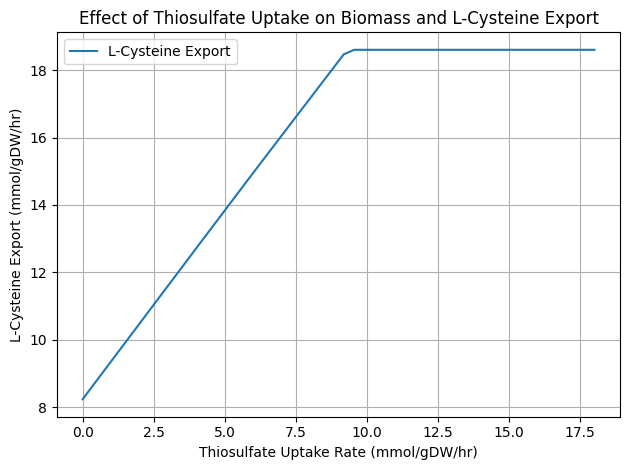

In [45]:
tsul_rates = np.linspace(0, 18, 50)
optimization_val = []
biomass_list = []
for rate in tsul_rates:
    enz_model.reactions.get_by_id('EX_tsul_e_reverse').bounds = (rate, rate)
    sol = enz_model.optimize()
    optimization_val.append(sol.objective_value)
    biomass_list.append(sol.fluxes['BIOMASS_Ec_iML1515_core_75p37M'])
results_df = pd.DataFrame({
    'Thiosulfate Uptake': tsul_rates,
    'L-Cysteine Export': optimization_val
})
plt.plot(tsul_rates, optimization_val, label= 'L-Cysteine Export')
plt.xlabel('Thiosulfate Uptake Rate (mmol/gDW/hr)')
plt.ylabel('L-Cysteine Export (mmol/gDW/hr)')
plt.legend()
plt.title('Effect of Thiosulfate Uptake on Biomass and L-Cysteine Export')
plt.grid(True)
plt.tight_layout()
plt.savefig('tsul_uptake_vs_output.png', dpi=300)
plt.show()

heatmaps 

Biomass objective check: 1.0*EX_cys__L_e - 1.0*EX_cys__L_e_reverse_41339


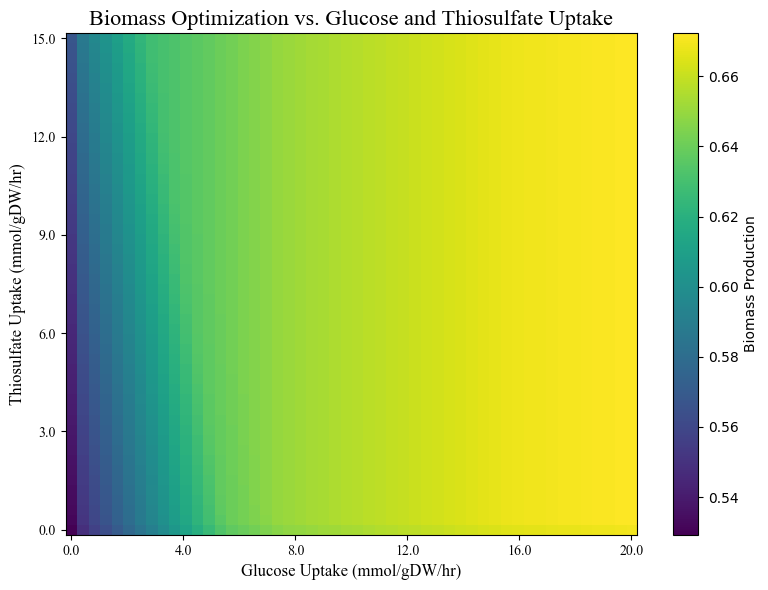

Biomass objective check: 1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685


In [40]:
print("Biomass objective check:", enz_model.objective.expression)
def optimal_conditions_glucose_tsul(model, precision, max_gluc, max_tsul):
    # Initialize results matrix
    plot = np.zeros([precision, precision])
    
    # Define glucose and thiosulfate uptake vectors
    glucose_vec = np.linspace(0, max_gluc, precision)
    tsul_vec = np.linspace(0, max_tsul, precision)

    for count_tsul, tsul in enumerate(tsul_vec):
        for count_gluc, gluc in enumerate(glucose_vec):
            # Set uptake bounds (forcing exact uptake)
            enz_model.reactions.get_by_id('EX_glc__D_e_reverse').bounds = (gluc, gluc)  # glucose uptake
            enz_model.reactions.get_by_id('EX_tsul_e_reverse').bounds = (tsul, tsul)  # thiosulfate uptake

            # Run FBA and record biomass production
            result = enz_model.optimize().objective_value
            if result < 0 or result is None:
                result = 0
            plot[(precision - 1 - count_tsul), count_gluc] = result  # invert Y for visualization

    # Setup ticks and labels
    label_gluc = np.round(np.linspace(0, max_gluc, 6), 1)
    label_tsul = np.round(np.linspace(max_tsul, 0, 6), 1)
    ticks = np.linspace(0, precision - 1, 6)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.imshow(plot, cmap='viridis', aspect='auto')
    plt.colorbar(label='Biomass Production')
    plt.title("Biomass Optimization vs. Glucose and Thiosulfate Uptake", fontsize=16, fontname='Times New Roman')
    plt.xlabel("Glucose Uptake (mmol/gDW/hr)", fontsize=12, fontname='Times New Roman')
    plt.ylabel("Thiosulfate Uptake (mmol/gDW/hr)", fontsize=12, fontname='Times New Roman')
    plt.xticks(ticks, label_gluc, fontsize=10, fontname='Times New Roman')
    plt.yticks(ticks, label_tsul, fontsize=10, fontname='Times New Roman')
    plt.grid(False)
    plt.tight_layout()
    plt.savefig("biomass_glucose_tsul_heatmap.png", dpi=300)
    plt.show()
    
    return plot

# Run the function with your model
enz_model.objective = 'BIOMASS_Ec_iML1515_core_75p37M'
biomassplot = optimal_conditions_glucose_tsul(model=enz_model, precision=50, max_gluc=20, max_tsul=15)
print("Biomass objective check:", enz_model.objective.expression)

xylose 

Biomass objective check: 1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685


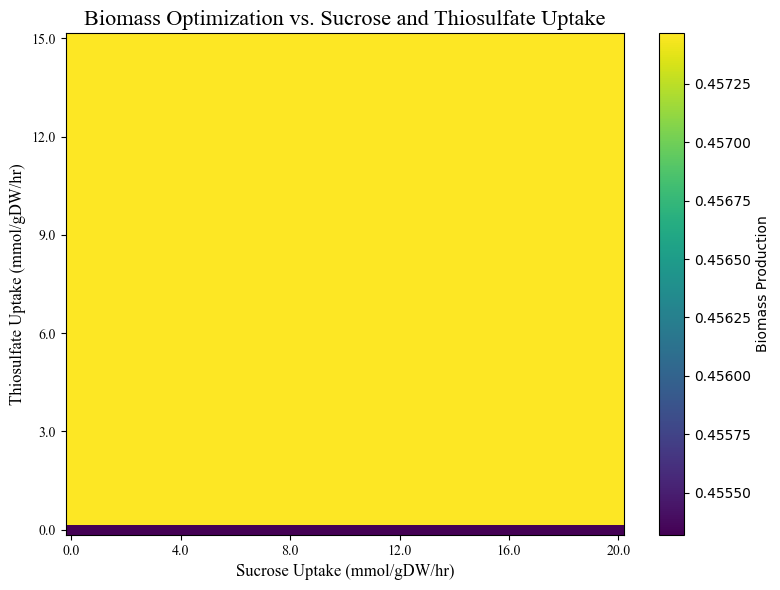

Biomass objective check: 1.0*BIOMASS_Ec_iML1515_core_75p37M - 1.0*BIOMASS_Ec_iML1515_core_75p37M_reverse_35685


In [38]:
#other carbon source, biomass optimization 
print("Biomass objective check:", enz_model.objective.expression)
def optimal_conditions_glucose_tsul(model, precision, max_carbon, max_tsul):
    # Initialize results matrix
    plot = np.zeros([precision, precision])
    
    # Define glucose and thiosulfate uptake vectors
    carbon_vec = np.linspace(0, max_carbon, precision)
    tsul_vec = np.linspace(0, max_tsul, precision)

    for count_tsul, tsul in enumerate(tsul_vec):
        for count_carbon, carbon in enumerate(carbon_vec):
            # Set uptake bounds (forcing exact uptake)
            #change
            enz_model.reactions.get_by_id('EX_sucr_e_reverse').bounds = (carbon, carbon)  # glucose uptake
            enz_model.reactions.get_by_id('EX_tsul_e_reverse').bounds = (tsul, tsul)  # thiosulfate uptake

            # Run FBA and record biomass production
            result = enz_model.optimize().objective_value
            if result < 0 or result is None:
                result = 0
            plot[(precision - 1 - count_tsul), count_carbon] = result  # invert Y for visualization

    # Setup ticks and labels
    label_gluc = np.round(np.linspace(0, max_carbon, 6), 1)
    label_tsul = np.round(np.linspace(max_tsul, 0, 6), 1)
    ticks = np.linspace(0, precision - 1, 6)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.imshow(plot, cmap='viridis', aspect='auto')
    plt.colorbar(label='Biomass Production')
    #change
    plt.title("Biomass Optimization vs. Sucrose and Thiosulfate Uptake", fontsize=16, fontname='Times New Roman')
    #change
    plt.xlabel("Sucrose Uptake (mmol/gDW/hr)", fontsize=12, fontname='Times New Roman')
    plt.ylabel("Thiosulfate Uptake (mmol/gDW/hr)", fontsize=12, fontname='Times New Roman')
    plt.xticks(ticks, label_gluc, fontsize=10, fontname='Times New Roman')
    plt.yticks(ticks, label_tsul, fontsize=10, fontname='Times New Roman')
    plt.grid(False)
    plt.tight_layout()
    #change
    plt.savefig("biomass_sucrose_tsul_heatmap.png", dpi=300)
    plt.show()
    
    return plot

# Run the function with your model
enz_model.objective = 'BIOMASS_Ec_iML1515_core_75p37M'
biomassplot = optimal_conditions_glucose_tsul(model=enz_model, precision=50, max_carbon=20, max_tsul=15)
print("Biomass objective check:", enz_model.objective.expression)

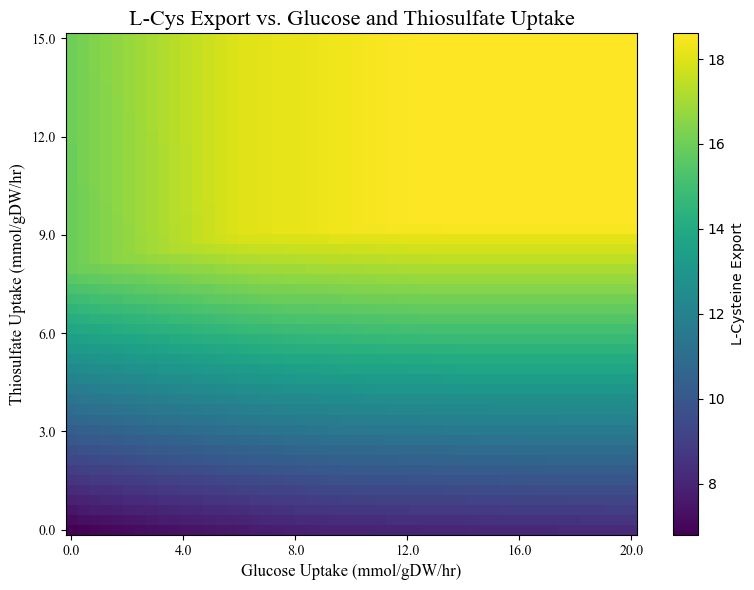

objective check: 1.0*EX_cys__L_e - 1.0*EX_cys__L_e_reverse_41339


In [42]:
def optimal_conditions_glucose_tsul(model, precision, max_gluc, max_tsul):
    # Initialize results matrix
    plot = np.zeros([precision, precision])
    
    # Define glucose and thiosulfate uptake vectors
    glucose_vec = np.linspace(0, max_gluc, precision)
    tsul_vec = np.linspace(0, max_tsul, precision)

    for count_tsul, tsul in enumerate(tsul_vec):
        for count_gluc, gluc in enumerate(glucose_vec):
            # Set uptake bounds (forcing exact uptake)
            enz_model.reactions.get_by_id('EX_glc__D_e_reverse').bounds = (gluc, gluc)  # glucose uptake
            enz_model.reactions.get_by_id('EX_tsul_e_reverse').bounds = (tsul, tsul)  # thiosulfate uptake

            # Run FBA and record l-cys production
            result = enz_model.optimize().objective_value
            if result < 0 or result is None:
                result = 0
            plot[(precision - 1 - count_tsul), count_gluc] = result  # invert Y for visualization

    # Setup ticks and labels
    label_gluc = np.round(np.linspace(0, max_gluc, 6), 1)
    label_tsul = np.round(np.linspace(max_tsul, 0, 6), 1)
    ticks = np.linspace(0, precision - 1, 6)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.imshow(plot, cmap='viridis', aspect='auto')
    plt.colorbar(label='L-Cysteine Export')
    plt.title("L-Cys Export vs. Glucose and Thiosulfate Uptake", fontsize=16, fontname='Times New Roman')
    plt.xlabel("Glucose Uptake (mmol/gDW/hr)", fontsize=12, fontname='Times New Roman')
    plt.ylabel("Thiosulfate Uptake (mmol/gDW/hr)", fontsize=12, fontname='Times New Roman')
    plt.xticks(ticks, label_gluc, fontsize=10, fontname='Times New Roman')
    plt.yticks(ticks, label_tsul, fontsize=10, fontname='Times New Roman')
    plt.grid(False)
    plt.tight_layout()
    plt.savefig("lcys_heatmap.png", dpi=300)
    plt.show()
    
    return plot

# Run the function with your model
enz_model.objective = 'EX_cys__L_e'
lcysplot = optimal_conditions_glucose_tsul(model=enz_model, precision=50, max_gluc=20, max_tsul=15)
print("objective check:", enz_model.objective.expression)

In [ ]:
xylose

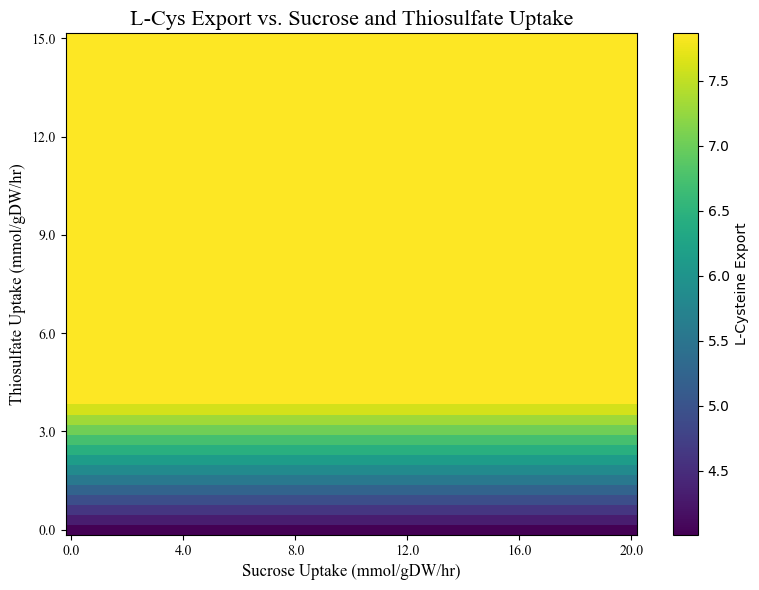

objective check: 1.0*EX_cys__L_e - 1.0*EX_cys__L_e_reverse_41339


In [39]:
#other carbon source l-cysteine export 
def optimal_conditions_glucose_tsul(model, precision, max_carbon, max_tsul):
    # Initialize results matrix
    plot = np.zeros([precision, precision])
    
    # Define glucose and thiosulfate uptake vectors
    carbon_vec = np.linspace(0, max_carbon, precision)
    tsul_vec = np.linspace(0, max_tsul, precision)

    for count_tsul, tsul in enumerate(tsul_vec):
        for count_carbon, carbon in enumerate(carbon_vec):
            # Set uptake bounds (forcing exact uptake)
            #change
            enz_model.reactions.get_by_id('EX_sucr_e_reverse').bounds = (carbon, carbon)  # glucose uptake
            enz_model.reactions.get_by_id('EX_tsul_e_reverse').bounds = (tsul, tsul)  # thiosulfate uptake

            # Run FBA and record l-cys production
            result = enz_model.optimize().objective_value
            if result < 0 or result is None:
                result = 0
            plot[(precision - 1 - count_tsul), count_carbon] = result  # invert Y for visualization

    # Setup ticks and labels
    label_gluc = np.round(np.linspace(0, max_carbon, 6), 1)
    label_tsul = np.round(np.linspace(max_tsul, 0, 6), 1)
    ticks = np.linspace(0, precision - 1, 6)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.imshow(plot, cmap='viridis', aspect='auto')
    plt.colorbar(label='L-Cysteine Export')
    #change
    plt.title("L-Cys Export vs. Sucrose and Thiosulfate Uptake", fontsize=16, fontname='Times New Roman')
    #Change
    plt.xlabel("Sucrose Uptake (mmol/gDW/hr)", fontsize=12, fontname='Times New Roman')
    plt.ylabel("Thiosulfate Uptake (mmol/gDW/hr)", fontsize=12, fontname='Times New Roman')
    plt.xticks(ticks, label_gluc, fontsize=10, fontname='Times New Roman')
    plt.yticks(ticks, label_tsul, fontsize=10, fontname='Times New Roman')
    plt.grid(False)
    plt.tight_layout()
    #change
    plt.savefig("sucrose_lcys_heatmap.png", dpi=300)
    plt.show()
    
    return plot

# Run the function with your model
enz_model.objective = 'EX_cys__L_e'
lcysplot = optimal_conditions_glucose_tsul(model=enz_model, precision=50, max_carbon=20, max_tsul=15)
print("objective check:", enz_model.objective.expression)

metabolic flux map 

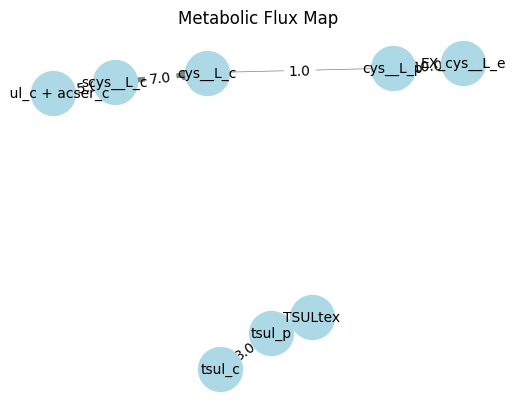

In [27]:
fluxes = {
    'TSULtex → tsul_p': 5.0,
    'tsul_p → tsul_c': 3.0,
    'tsul_c + acser_c → scys__L_c': 15.0,
    'scys__L_c → cys__L_c': 7.0,
    'cys__L_c → cys__L_p': 1.0,
    'cys__L_p → EX_cys__L_e': 10.0
}

# Build graph
G = nx.DiGraph()

for reaction, flux in fluxes.items():
    src, dst = reaction.split(" → ")
    G.add_edge(src, dst, weight=flux)

# Position nodes with a layout (e.g. spring or shell layout)
pos = nx.spring_layout(G)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=1000)

# Draw edges with thickness based on flux
edges = G.edges(data=True)
nx.draw_networkx_edges(G, pos, edgelist=edges,
                       width=[abs(d['weight']) / 2 for (_, _, d) in edges],
                       edge_color='gray', arrows=True)

# Add labels
nx.draw_networkx_labels(G, pos, font_size=10)
edge_labels = {(u, v): f"{d['weight']:.1f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Metabolic Flux Map")
plt.axis('off')
plt.show()

top reactions 

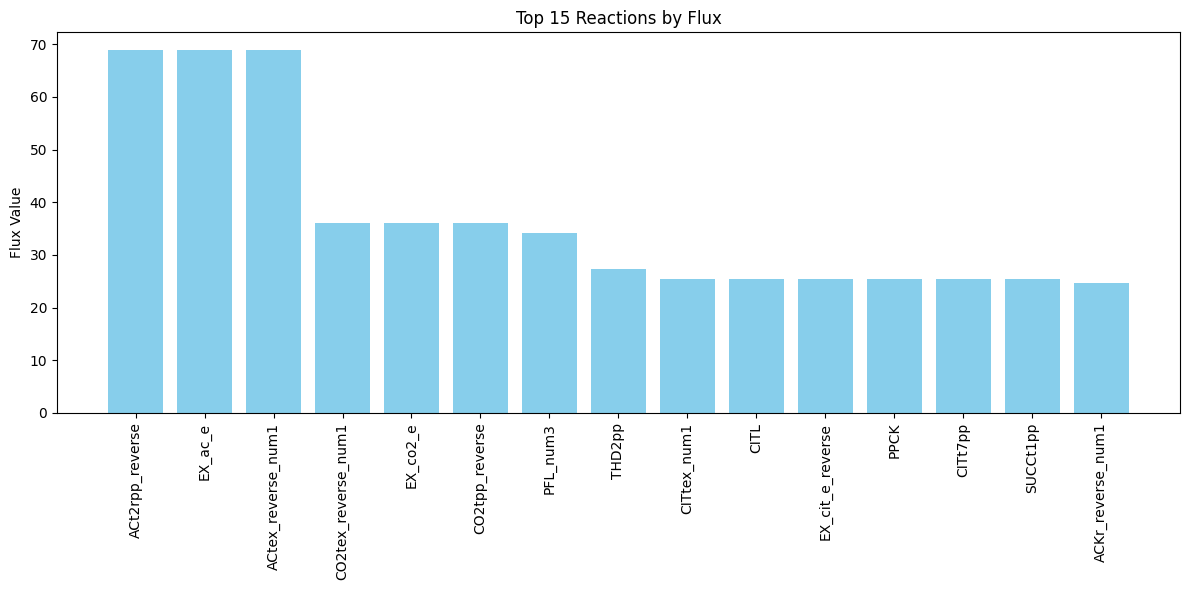

<Figure size 640x480 with 0 Axes>

In [32]:
flux_df = pfba_solution.to_frame()
flux_df['abs_flux'] = flux_df['fluxes'].abs()

# Get top N reactions by absolute flux
top_n = 15  # or 10, 20, etc.
top_fluxes = flux_df.sort_values(by='abs_flux', ascending=False).head(top_n)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(top_fluxes.index, top_fluxes['fluxes'], color='skyblue')
plt.xticks(rotation=90)
plt.ylabel('Flux Value')
plt.title(f'Top {top_n} Reactions by Flux')
plt.tight_layout()
plt.show()
plt.savefig("top_flux_reactions.png", dpi=300) 

In [30]:

for rxn in pfba_solution_df.fluxes.index:
    flux = pfba_solution_df.fluxes[rxn]
    if abs(flux) > 1e-6:
        print(f"{rxn}: {flux}")

#save_json_model(enz_model, "visualization.json")
write_sbml_model(enz_model, "enz_model_output.xml")

XPPT: 0.0170783444227836
SHK3Dr: 6.263211153782933e-05
NDPK6_num1: 0.0018372554153574237
OMPDC: 0.023226893874614355
ACALD_num1: 9.307519000585858
APRAUR: 3.131605576891429e-05
PPCK: 25.480534815298313
DB4PS: 6.263211153782858e-05
ALAR_num1: 0.0029267171223315816
RBFK: 1.5658027884457142e-05
RBK: 0.01701571231124577
RBFSb: 3.131605576891429e-05
SHCHD2: 1.5658027884457145e-05
EX_co2_e: 36.04042630019438
GTHOr: 9.307479002390288
RBFSa: 6.263211153782858e-05
PSCVT: 6.263211153782933e-05
CHORS: 6.263211153782934e-05
EX_h_e: 1.6669586599131845
DMATT: 1.9519873326812195e-05
GRTT: 1.951987332681219e-05
UPP3S: 3.131605576891429e-05
UPPDC1: 1.5658027884457145e-05
EX_ac_e: 68.82085377495542
EX_akg_e: 4.672001347870312
EX_succ_e: 0.023266986851842426
MOAT: 0.0013661102713901265
UDCPDPS: 3.861845442355051e-06
USHD: 0.001366110271390127
ENO: 8.73494265063248
LPADSS: 0.001366110271390127
GLUTRS: 0.00025052844615131427
TDSK: 0.001366110271390127
PGI: 2.9207475484987095
PGL: 10.558573963661964
RPE: 7.

In [23]:
#run genome-scale metabolic model
norm_model=cobra.io.json.load_json_model(json_round1_output_file)
norm_model.objective = 'EX_cys__L_e'
#norm_model.reactions.get_by_id('EX_glc__D_e_reverse').bounds = (13, 13)
pfba_solution = cobra.flux_analysis.pfba(norm_model)
pfba_solution_df = pfba_solution.to_frame()
pfba_solution_df.to_csv('./analysis/Orimodel_solution_df_pfba.csv')
print("LYCS", pfba_solution.fluxes['EX_cys__L_e'])
print("Biomass", pfba_solution.fluxes['BIOMASS_Ec_iML1515_core_75p37M'])

norm_model.objective = 'BIOMASS_Ec_iML1515_core_75p37M'
#norm_model.reactions.get_by_id('EX_glc__D_e_reverse').bounds = (13, 13)
pfba_solution = cobra.flux_analysis.pfba(norm_model)
pfba_solution_df = pfba_solution.to_frame()
pfba_solution_df.to_csv('./analysis/Orimodel_solution_df_pfba.csv')
print("LYCS", pfba_solution.fluxes['EX_cys__L_e'])
print("Biomass", pfba_solution.fluxes['BIOMASS_Ec_iML1515_core_75p37M'])

LYCS 9.83950103950107
Biomass 0.0
LYCS 0.0
Biomass 0.8697726420320029
